## Model agnostic recipe to evaluate model SST with satellite image product 


**This recipe will show an example onto how to evaluate the model SST over a satellite image. In this example, the satellite image product chosen is OSTIA, and 2 models examples (ROMS and MOM6) are shown for the East Australian current region. Examples for the timemean and seasonal cycle will be given**

Steps:
- Read model and satellite data
- Interpolate the higher-resolution data to the coarser to get the same points and same area
- Calculate the time-mean
- Check the differences
- Calculate the seasonality and compare
- Calculate RMSE

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
from dask.distributed import Client
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42863,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41473,Total threads: 1
Dashboard: /proxy/45141/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:33741,


In [2]:
#Model specific information.
#note that we are currently calling coordinates (lat_var, lon_var etc) in each step using this notation: lon_var= model_args[model]['lon_var']
#we could simplify by using cf_xarray https://cf-xarray.readthedocs.io/en/latest/index.html
model_args = {
              "roms": {"data_var": "temp",
                       "lat_var": "lat_rho",
                       "lon_var": "lon_rho",
                       "time_var": 'ocean_time',
                       "z_var": "s_rho",
                       "z_inx": -1,
                       "file_name":'/g/data/yj27/users/cgk561/30yr_run_1993_2023_CK/output/roms_his_08[34567]*',

             },
              "mom6": { "data_var": "thetao",
                       "lat_var": "yh",
                       "lon_var": "xh",
                       'time_var': 'time',
                       "z_var": "z_l",
                       "z_inx": 0,
                       "file_name": "/g/data/av17/access-nri/rOM3/superaus/v20260619/expt08_outputs3/output*/access-om3.mom6.3d.thetao.1day.mean*.nc",
 
              }
}

In [3]:
#Spefifying the region and models we want to investigate:
lon_min = 145
lon_max = 165
lat_min = -42
lat_max = -24
models = ['roms', 'mom6']

In [4]:
# Reading the data. Adjust the path according to where your data is and its name.
# OSTIA data is in Kelvin, so we convert it to Celsius.
# This step takes a while
temp = {}
for model in models:
    varname = model_args[model]['data_var']
    files = model_args[model]['file_name']
    time_var = model_args[model]['time_var']
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    temp[model] = xr.open_mfdataset(files, parallel=True, decode_timedelta=True,chunks={time_var: 1, lat_var: 'auto', lon_var: 'auto'} )[varname]
    temp[model] = temp[model].drop_duplicates(time_var, keep='first')
 
ostia_all = xr.open_mfdataset('/g/data/yj27/data/obs/ostia/METOFFICE-GLO-SST-L4-REP-OBS-SST_*.nc',chunks='auto', parallel=True).analysed_sst - 273.15



/jobfs/172351047.gadi-pbs/ipykernel_1883058/726022974.py:12: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  temp[model] = xr.open_mfdataset(files, parallel=True, decode_timedelta=True,chunks={time_var: 1, lat_var: 'auto', lon_var: 'auto'} )[varname]
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:767: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/sit

In [5]:
#subsetting to surface only for models that output 3d variables
for model in models:
    if 'z_var' in model_args[model]:
        z_var = model_args[model]['z_var']
        z_inx = model_args[model]['z_inx']
        temp[model] = temp[model].isel({z_var: z_inx})


In [6]:
# Selecting the same time for roms, mom and ostia - said to be occuring at the same time if only 12 hours apart (method='nearest',tolerance='12h')

#subsetting OSTIA recurssivly by subsetting time matches with each model indiviually
for model in models:
    time_var = model_args[model]['time_var']
    ostia = ostia_all.reindex(time=temp[model][time_var].values, method='nearest',tolerance='12h').dropna(dim='time', how='all')
    ostia = ostia.drop_duplicates('time', keep='first')
#The subsetted ostia times will now be the overlap between all models and ostia     
target_times = ostia.time.values

for model in models:
    time_var = model_args[model]['time_var']
    temp[model] = temp[model].reindex({time_var: target_times}, method='nearest',tolerance='12h')




In [7]:
#Subsettng by lat and lon 
for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    mask = ( (temp[model][lat_var] < lat_max) & (temp[model][lat_var] > lat_min)  & (temp[model][lon_var] >lon_min) &  (temp[model][lon_var]<lon_max)).compute()
    temp[model] = temp[model].where(mask, drop=True)

mask = ( (ostia.latitude < lat_max) & (ostia.latitude > lat_min)  & (ostia.longitude >lon_min) &  (ostia.longitude<lon_max) ).compute()
ostia = ostia.where(mask, drop=True)

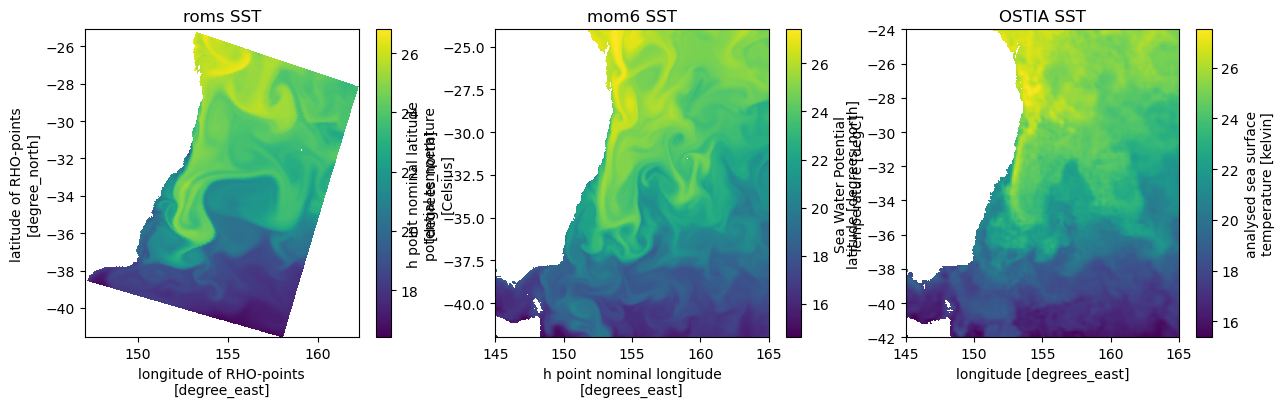

In [8]:
# Checking one day for our SST roms data

ncols = len(model_args) +1
fig, ax = plt.subplots(ncols=ncols, figsize=(ncols*5, 4))
n = 0
for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    temp[model].isel({time_var:0}).plot(ax=ax[n], x=lon_var, y=lat_var)
    ax[n].set_title(model + ' SST')
    n = n+1

ostia.isel(time=0).plot(ax=ax[n], x='longitude', y='latitude')
ax[n].set_title('OSTIA SST');



In [9]:
# Checking grid resolution (OSTIA is 0.05° and ROMS is variable from 0.02 to 0.06)

for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    leng = len(temp[model][lat_var].sizes)
    if leng <2.0:
        print(model, '  grid resolution:', temp[model][lon_var][1] - temp[model][lon_var][0], temp[model][lat_var][1] - temp[model][lat_var][0])
        print("creating 2d lat / lon for", model)
        LON, LAT = np.meshgrid(temp[model][lon_var].values, temp[model][lat_var].values)
        temp[model] = temp[model].assign_coords(y2d=(("yh", "xh"), LAT))
        temp[model] = temp[model].assign_coords(x2d=(("yh", "xh"), LON))
        model_args[model]['lat_var'] = 'y2d'
        model_args[model]['lon_var'] = 'x2d'
    else: 
        print(model, ' grid resolution:', temp[model][lon_var][0, 1] - temp[model][lon_var][0, 0], temp[model][lat_var][1, 0] - temp[model][lat_var][0, 0])



roms  grid resolution: <xarray.DataArray 'lon_rho' ()> Size: 8B
array(0.03247193)
Coordinates:
    s_rho    float64 8B -0.004799
Attributes:
    standard_name:  grid_longitude_at_cell_center
    long_name:      longitude of RHO-points
    units:          degree_east
    field:          lon_rho <xarray.DataArray 'lat_rho' ()> Size: 8B
array(0.04234901)
Coordinates:
    s_rho    float64 8B -0.004799
Attributes:
    standard_name:  grid_latitude_at_cell_center
    long_name:      latitude of RHO-points
    units:          degree_north
    field:          lat_rho
mom6   grid resolution: <xarray.DataArray 'xh' ()> Size: 8B
array(0.03333333)
Coordinates:
    z_l      float64 8B 1.092
Attributes:
    units:      degrees_east
    long_name:  h point nominal longitude
    axis:       X <xarray.DataArray 'yh' ()> Size: 8B
array(0.02995868)
Coordinates:
    z_l      float64 8B 1.092
Attributes:
    units:      degrees_north
    long_name:  h point nominal latitude
    axis:       Y
creating 2d la

In [31]:
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator
# Interpolate model grid to OSTIA grid (higher resolution into coarser resolution)
LON, LAT = np.meshgrid(ostia.longitude, ostia.latitude)
temp_regrided = {}

for model in models:
    print('Starting for model ', model)
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    points = np.array([temp[model][lon_var].values.ravel(), temp[model][lat_var].values.ravel()]).T
    # List to store regridded time steps
    regridded_list = []
    #Calculating interpolation weights in advance to speed this up. 
    #We could also go to inbuilt x-array interpolation methods -  but this method will be easier to add unstructured later

    print("Building source triangulation grid...")
    triangulation = Delaunay(points) 
    target_coords = np.column_stack((LON.ravel(), LAT.ravel()))
    for TT in temp[model][time_var].values:
        print(TT)
        # Extract values for the current time step
        values = temp[model].sel({time_var: TT}).values.ravel()
        # Interpolate onto OSTIA grid
        fast_interpolator = LinearNDInterpolator(triangulation, values, fill_value=np.nan)
        interpolated_flat = fast_interpolator(target_coords)
        interpolated = interpolated_flat.reshape(LON.shape)
        #interpolated = griddata(points, values, (LON, LAT), method='linear')
        # Convert interpolated result to a DataArray with correct dimensions
        interpolated_da = xr.DataArray(
        interpolated,
        dims=("latitude", "longitude"),
        coords={"latitude": ostia.latitude, "longitude": ostia.longitude, "time": TT},
        )
        # Append to list
        regridded_list.append(interpolated_da)

    # Concatenate along time dimension
    temp_regrided[model] = xr.concat(regridded_list, dim="time")

Starting for model  roms
Building source triangulation grid...
2013-01-01T12:00:00.000000000
2013-01-02T12:00:00.000000000
2013-01-03T12:00:00.000000000
2013-01-04T12:00:00.000000000
2013-01-05T12:00:00.000000000
2013-01-06T12:00:00.000000000
2013-01-07T12:00:00.000000000
2013-01-08T12:00:00.000000000
2013-01-09T12:00:00.000000000
2013-01-10T12:00:00.000000000
2013-01-11T12:00:00.000000000
2013-01-12T12:00:00.000000000
2013-01-13T12:00:00.000000000
2013-01-14T12:00:00.000000000
2013-01-15T12:00:00.000000000
2013-01-16T12:00:00.000000000
2013-01-17T12:00:00.000000000
2013-01-18T12:00:00.000000000
2013-01-19T12:00:00.000000000
2013-01-20T12:00:00.000000000
2013-01-21T12:00:00.000000000
2013-01-22T12:00:00.000000000
2013-01-23T12:00:00.000000000
2013-01-24T12:00:00.000000000
2013-01-25T12:00:00.000000000
2013-01-26T12:00:00.000000000
2013-01-27T12:00:00.000000000
2013-01-28T12:00:00.000000000
2013-01-29T12:00:00.000000000
2013-01-30T12:00:00.000000000
2013-01-31T12:00:00.000000000
2013-02

In [32]:
# Let's mask ostia data to match only the part of the roms data.
# Doing for roms as well, to remove the big nan area created by the interpolation.

temp_masked = {}
for model in models:
    ostia_masked = ostia.where(~np.isnan(temp_regrided[model]), drop=True)
    ostia = ostia_masked


for model in models:
    tmp1 = temp_regrided[model].compute()
    tmp2 = ~np.isnan(ostia_masked).compute()
    temp_masked[model] = tmp1.where(tmp2, drop=True)
    
#roms_masked = roms_regrided.where(~np.isnan(roms_regrided), drop=True)
#mom_masked = mom_regrided.where(~np.isnan(roms_masked), drop=True)





In [11]:
# Doing the time-mean
temp_timemean = {}
temp_std = {}
ostia_timemean = ostia_masked.mean('time')
ostia_std = ostia_masked.std('time')

for model in models:
    temp_timemean[model] = temp_masked[model].mean('time')
    temp_std[model] = temp_masked[model].std('time')


#roms_timemean = roms_masked.mean('time')
#mom_timemean = mom_masked.mean('time')
#ostia_timemean = ostia_masked.mean('time')

#roms_std = roms_masked.std('time')
#mom_std = mom_masked.std('time')
#ostia_std = ostia_masked.std('time')

In [12]:
# Calculating the difference from the time-mean
diff_temp = {}
for model in models:
    diff_temp[model] = ostia_timemean - temp_timemean[model]


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 68.12 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountere

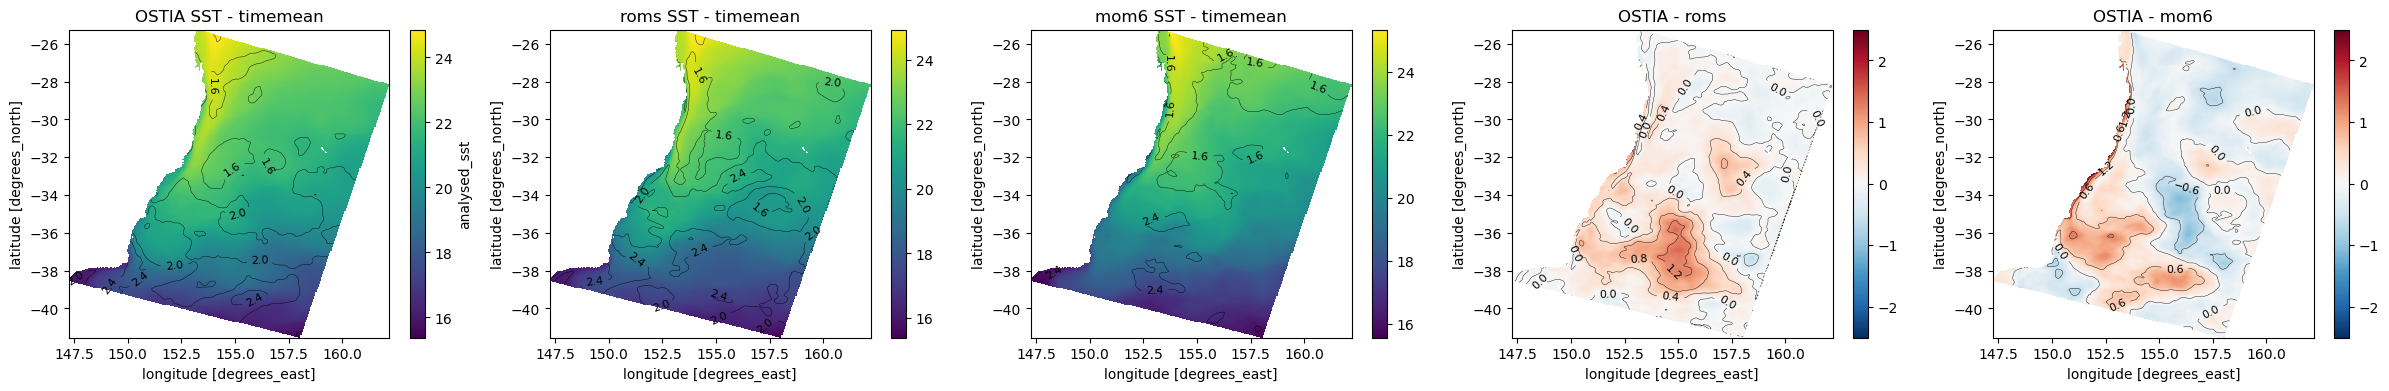

In [13]:
# Checking the timemean comparison
nomodels = len(models)
ncols=2*nomodels +1
fig, ax = plt.subplots(ncols=ncols, figsize=(6*ncols, 4))

n = 0 #column number
ostia_timemean.plot(ax=ax[n])
cnt = ostia_std.plot.contour(ax=ax[n], levels=5, colors=['k'], linewidths=0.3)
plt.clabel(cnt, inline=True, fontsize=8)
ax[n].set_title('OSTIA SST - timemean');
n = n+1

for model in models:
    temp_timemean[model].plot(ax=ax[n])
    cnt = temp_std[model].plot.contour(ax=ax[n], levels=5, colors=['k'], linewidths=0.3)
    plt.clabel(cnt, inline=True, fontsize=8)
    ax[n].set_title(model + ' SST - timemean')
    n = n+1
    
for model in models:
    diff_temp[model].plot(ax=ax[n], vmin=-2.5, vmax=2.5, cmap='RdBu_r')
    cnt = diff_temp[model].plot.contour(ax=ax[n], levels=10, colors=['k'], linewidths=0.3)
    plt.clabel(cnt, inline=True, fontsize=8)
    ax[n].set_title('OSTIA - ' + model);
    n = n+1


<br>

### **Doing the seasonal analysis**

In [14]:
# Grouping the data in seasons
ostia_seasons = ostia_masked.groupby('time.season')
temp_seasons = {}
for model in models:
    temp_seasons[model] = temp_masked[model].groupby('time.season')

#roms_seasons = roms_masked.groupby('time.season')
#mom_seasons = mom_masked.groupby('time.season')
#ostia_seasons = ostia_masked.groupby('time.season')

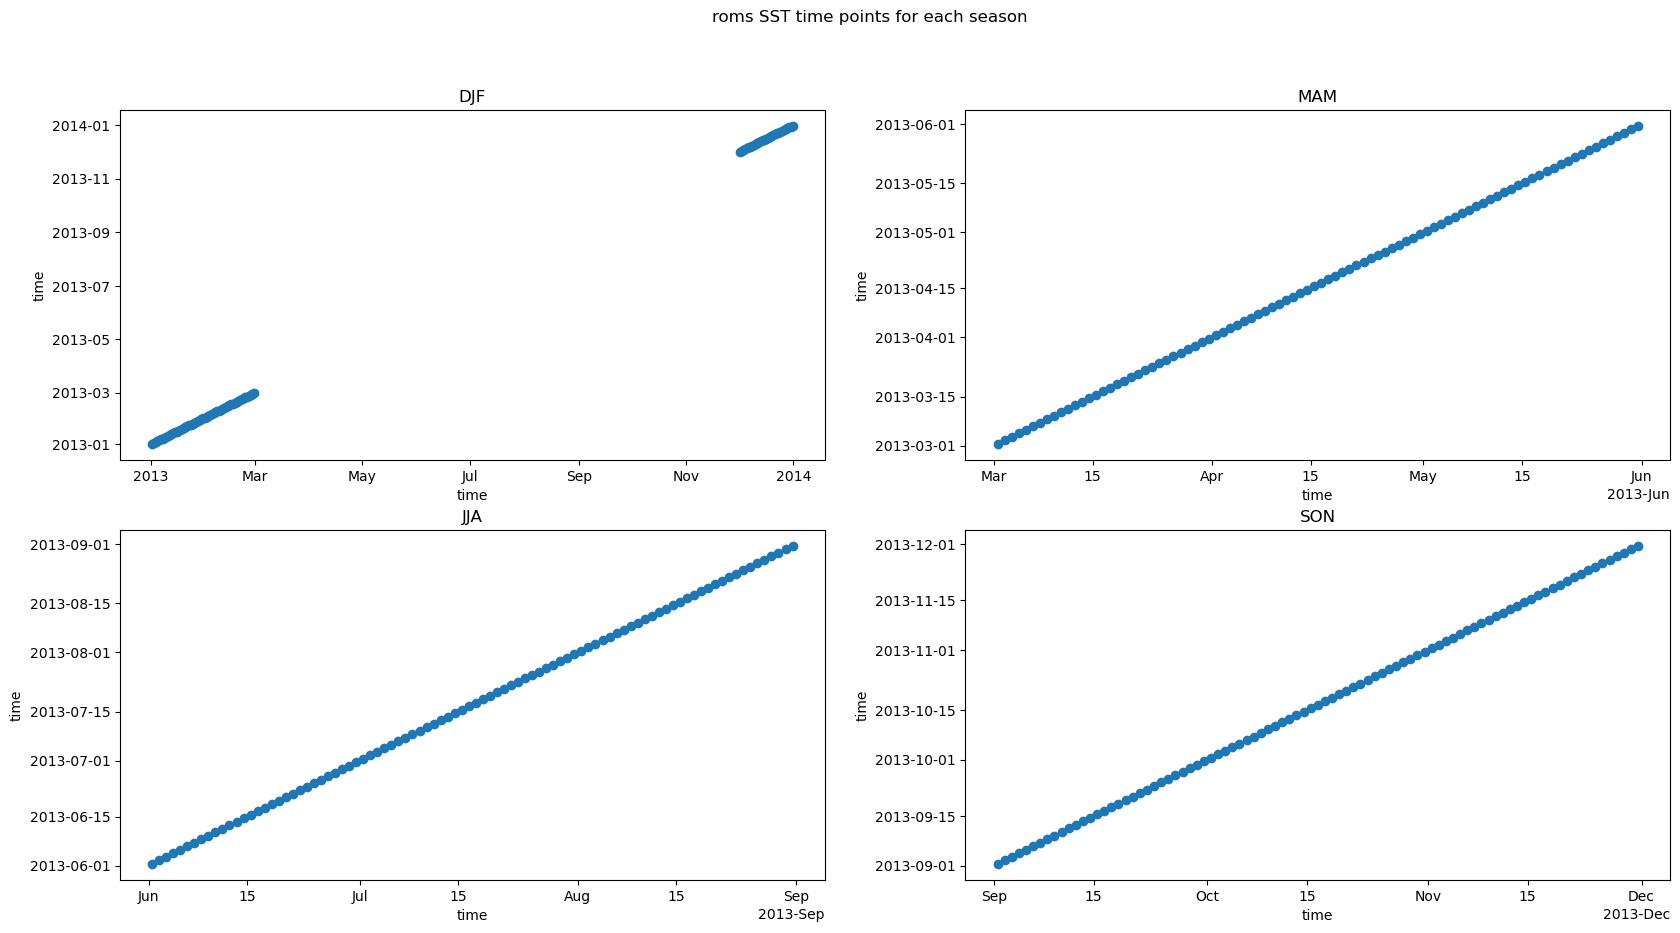

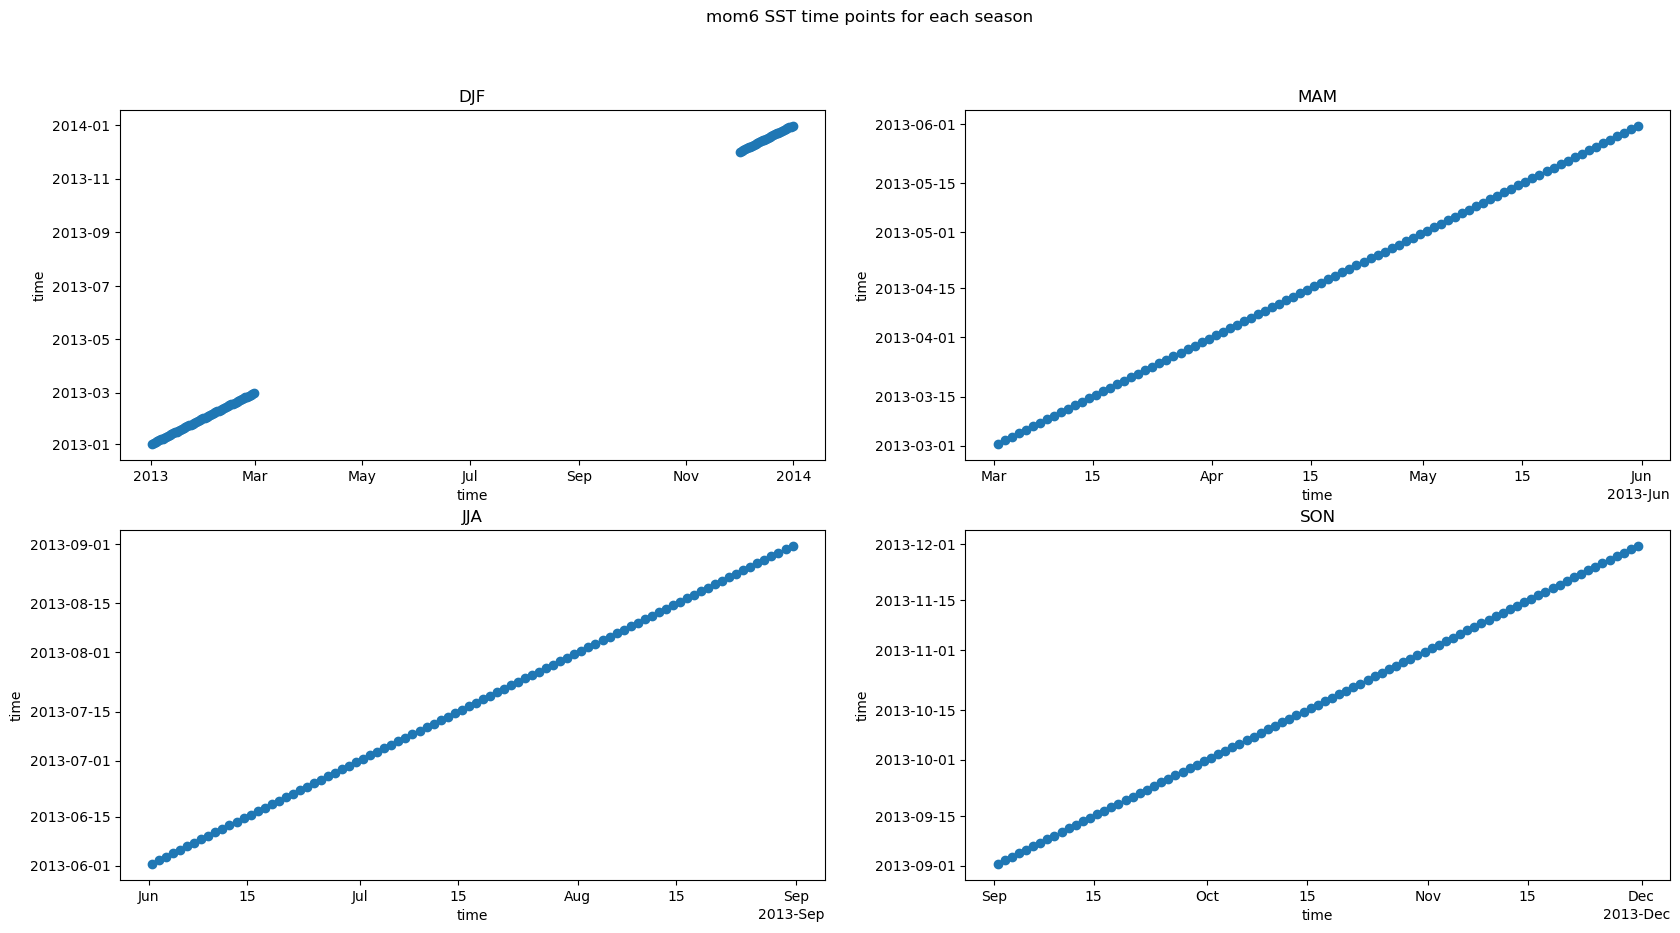

In [19]:
# Plotting the time points for DJF season without connecting the markers

for model in models:
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(20, 10))
    temp_seasons[model]['DJF'].time.plot(ax=ax[0, 0], marker='o', linestyle='None'); ax[0, 0].set_title('DJF')
    temp_seasons[model]['MAM'].time.plot(ax=ax[0, 1], marker='o', linestyle='None'); ax[0, 1].set_title('MAM')
    temp_seasons[model]['JJA'].time.plot(ax=ax[1, 0], marker='o', linestyle='None'); ax[1, 0].set_title('JJA')
    temp_seasons[model]['SON'].time.plot(ax=ax[1, 1], marker='o', linestyle='None'); ax[1, 1].set_title('SON');
    fig.suptitle(model + ' SST time points for each season');


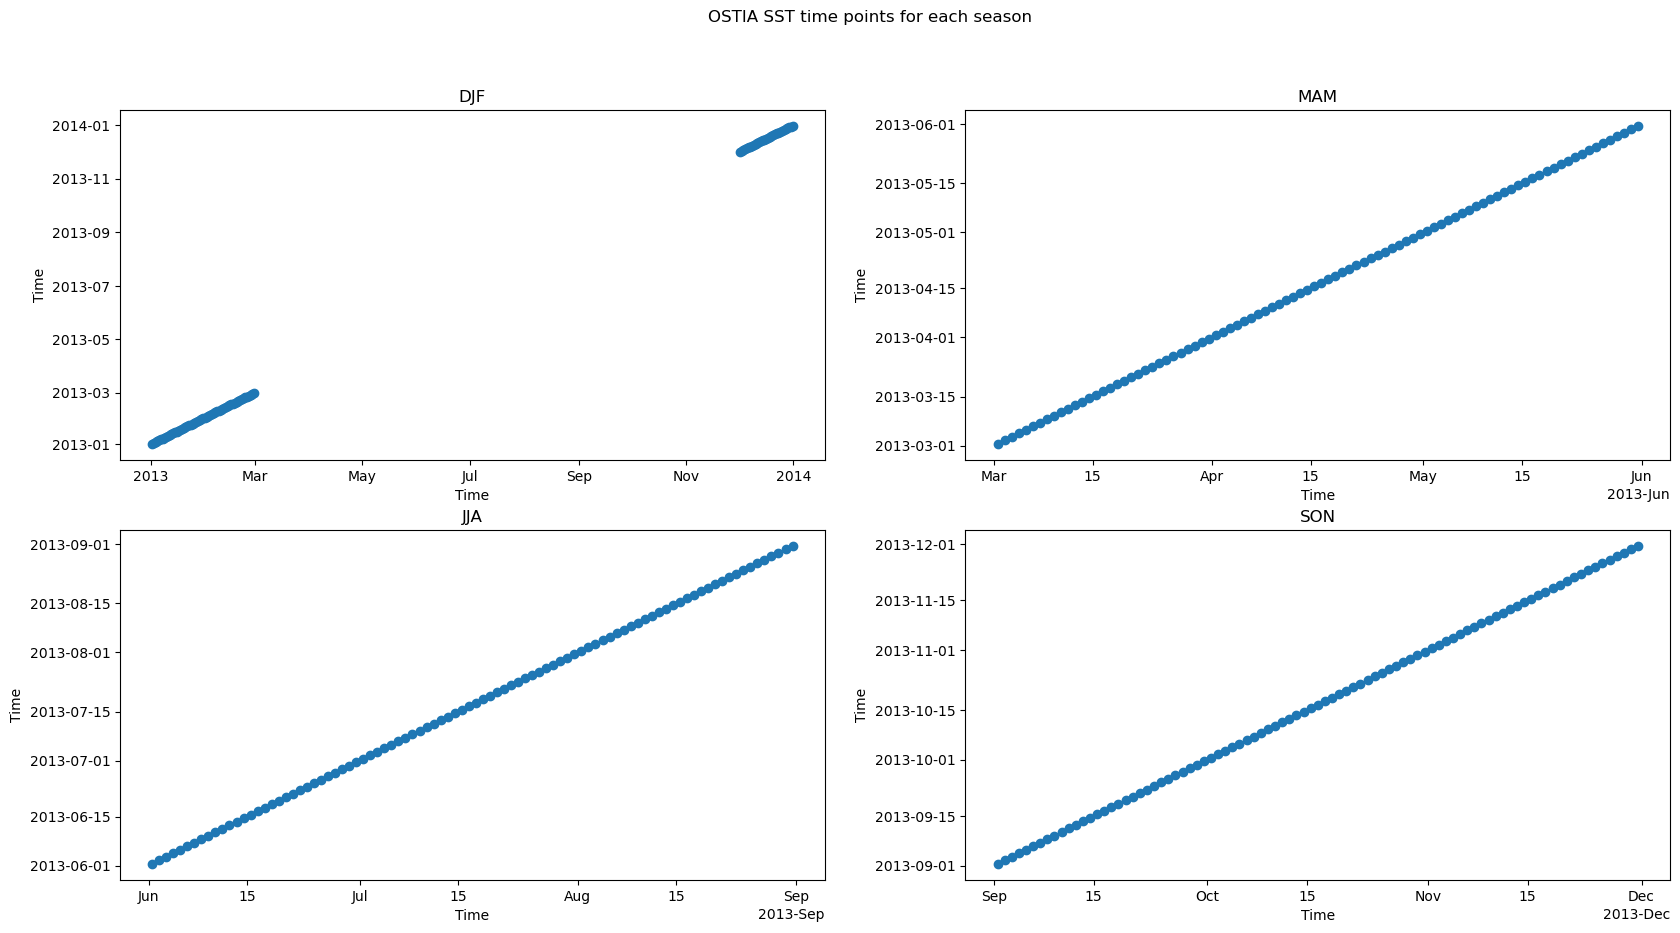

In [20]:
# Plotting the time points for DJF season without connecting the markers
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(20, 10))

ostia_seasons['DJF'].time.plot(ax=ax[0, 0], marker='o', linestyle='None'); ax[0, 0].set_title('DJF')
ostia_seasons['MAM'].time.plot(ax=ax[0, 1], marker='o', linestyle='None'); ax[0, 1].set_title('MAM')
ostia_seasons['JJA'].time.plot(ax=ax[1, 0], marker='o', linestyle='None'); ax[1, 0].set_title('JJA')
ostia_seasons['SON'].time.plot(ax=ax[1, 1], marker='o', linestyle='None'); ax[1, 1].set_title('SON');
fig.suptitle('OSTIA SST time points for each season');

In [21]:
# Now we know the our seasonal data is correct, let's calculate the seasonal mean
ostia_seasons_mean = ostia_seasons.mean('time')
ostia_seasons_std = ostia_seasons.std('time')
temp_seasons_mean = {}
temp_seasons_std = {}
for model in models:
    temp_seasons_mean[model] = temp_seasons[model].mean('time')
    temp_seasons_std[model] = temp_seasons[model].std('time')


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 68.87 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 68.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/cli

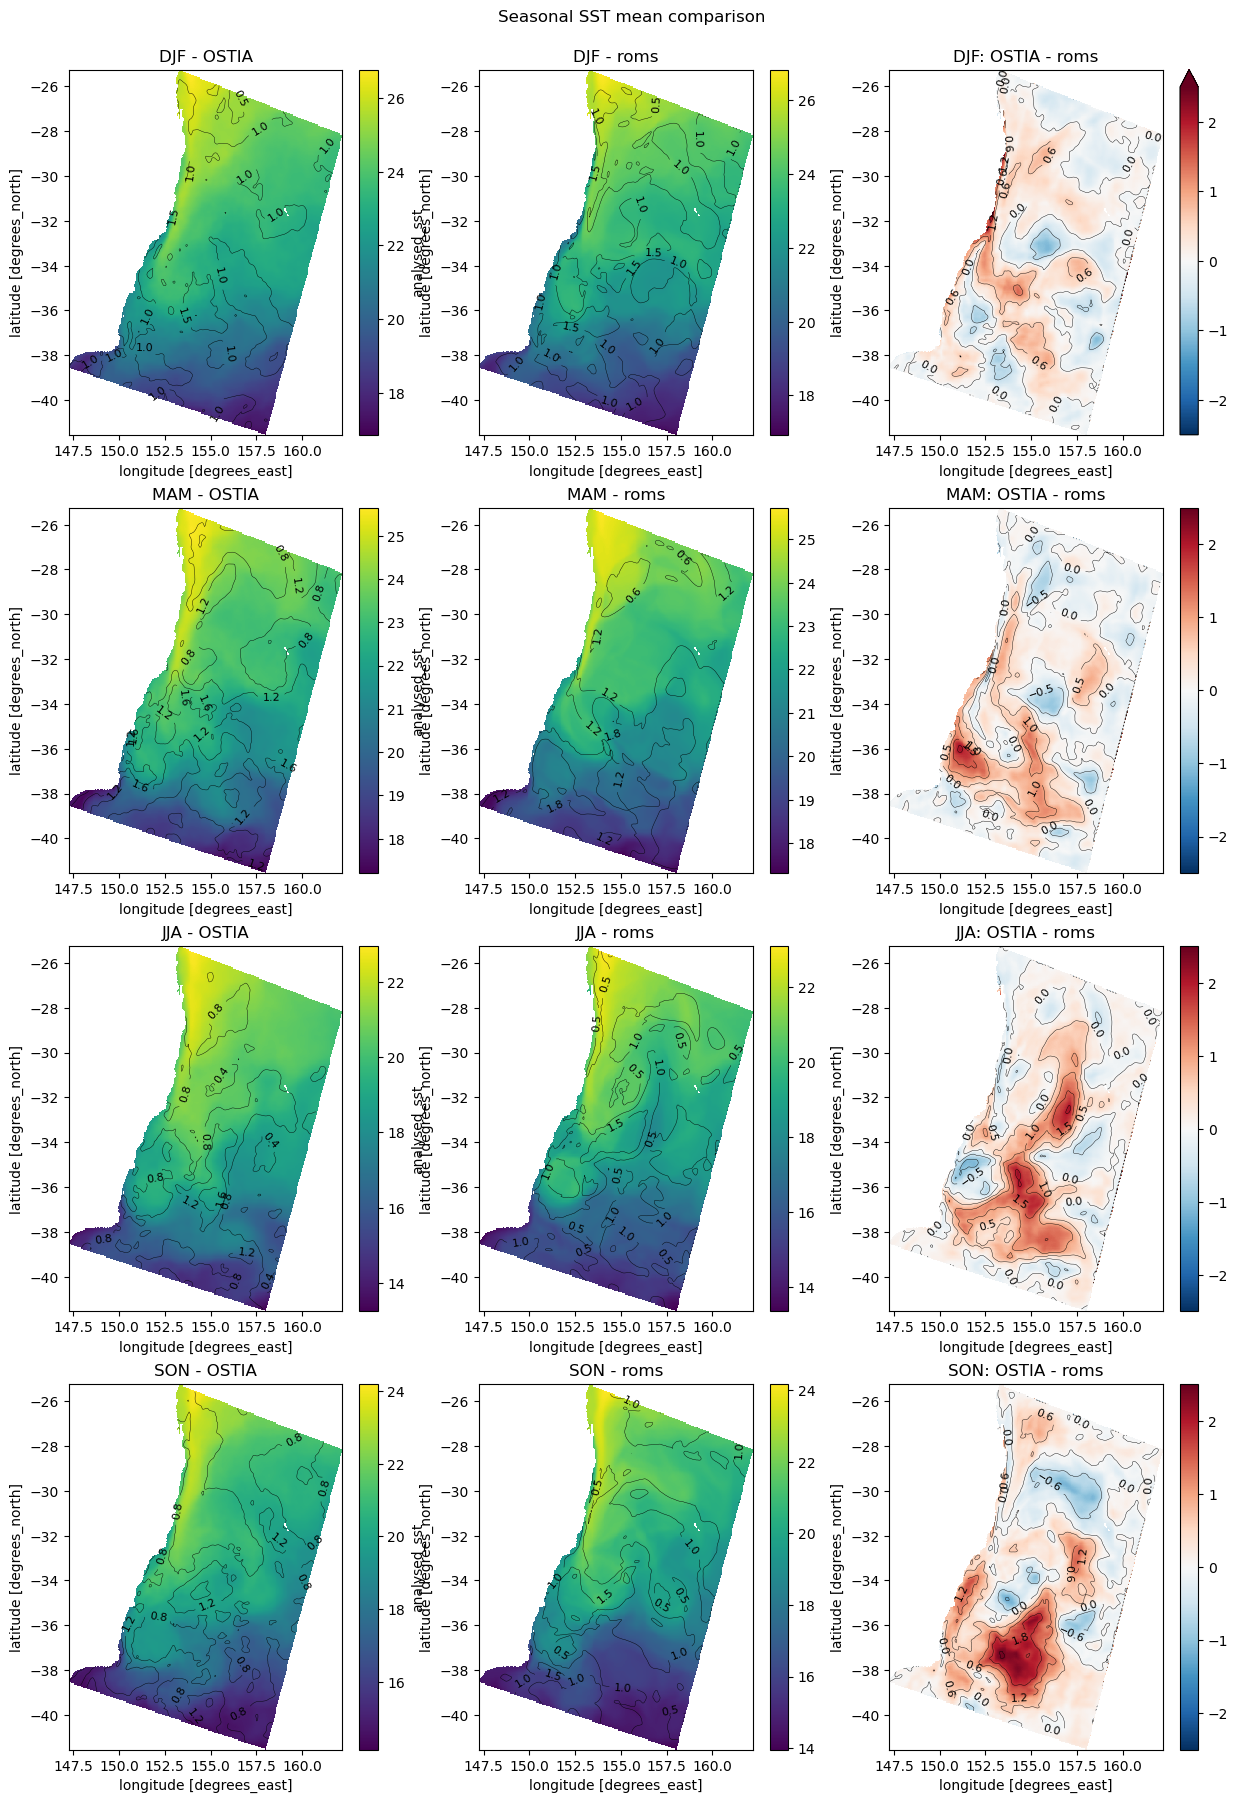

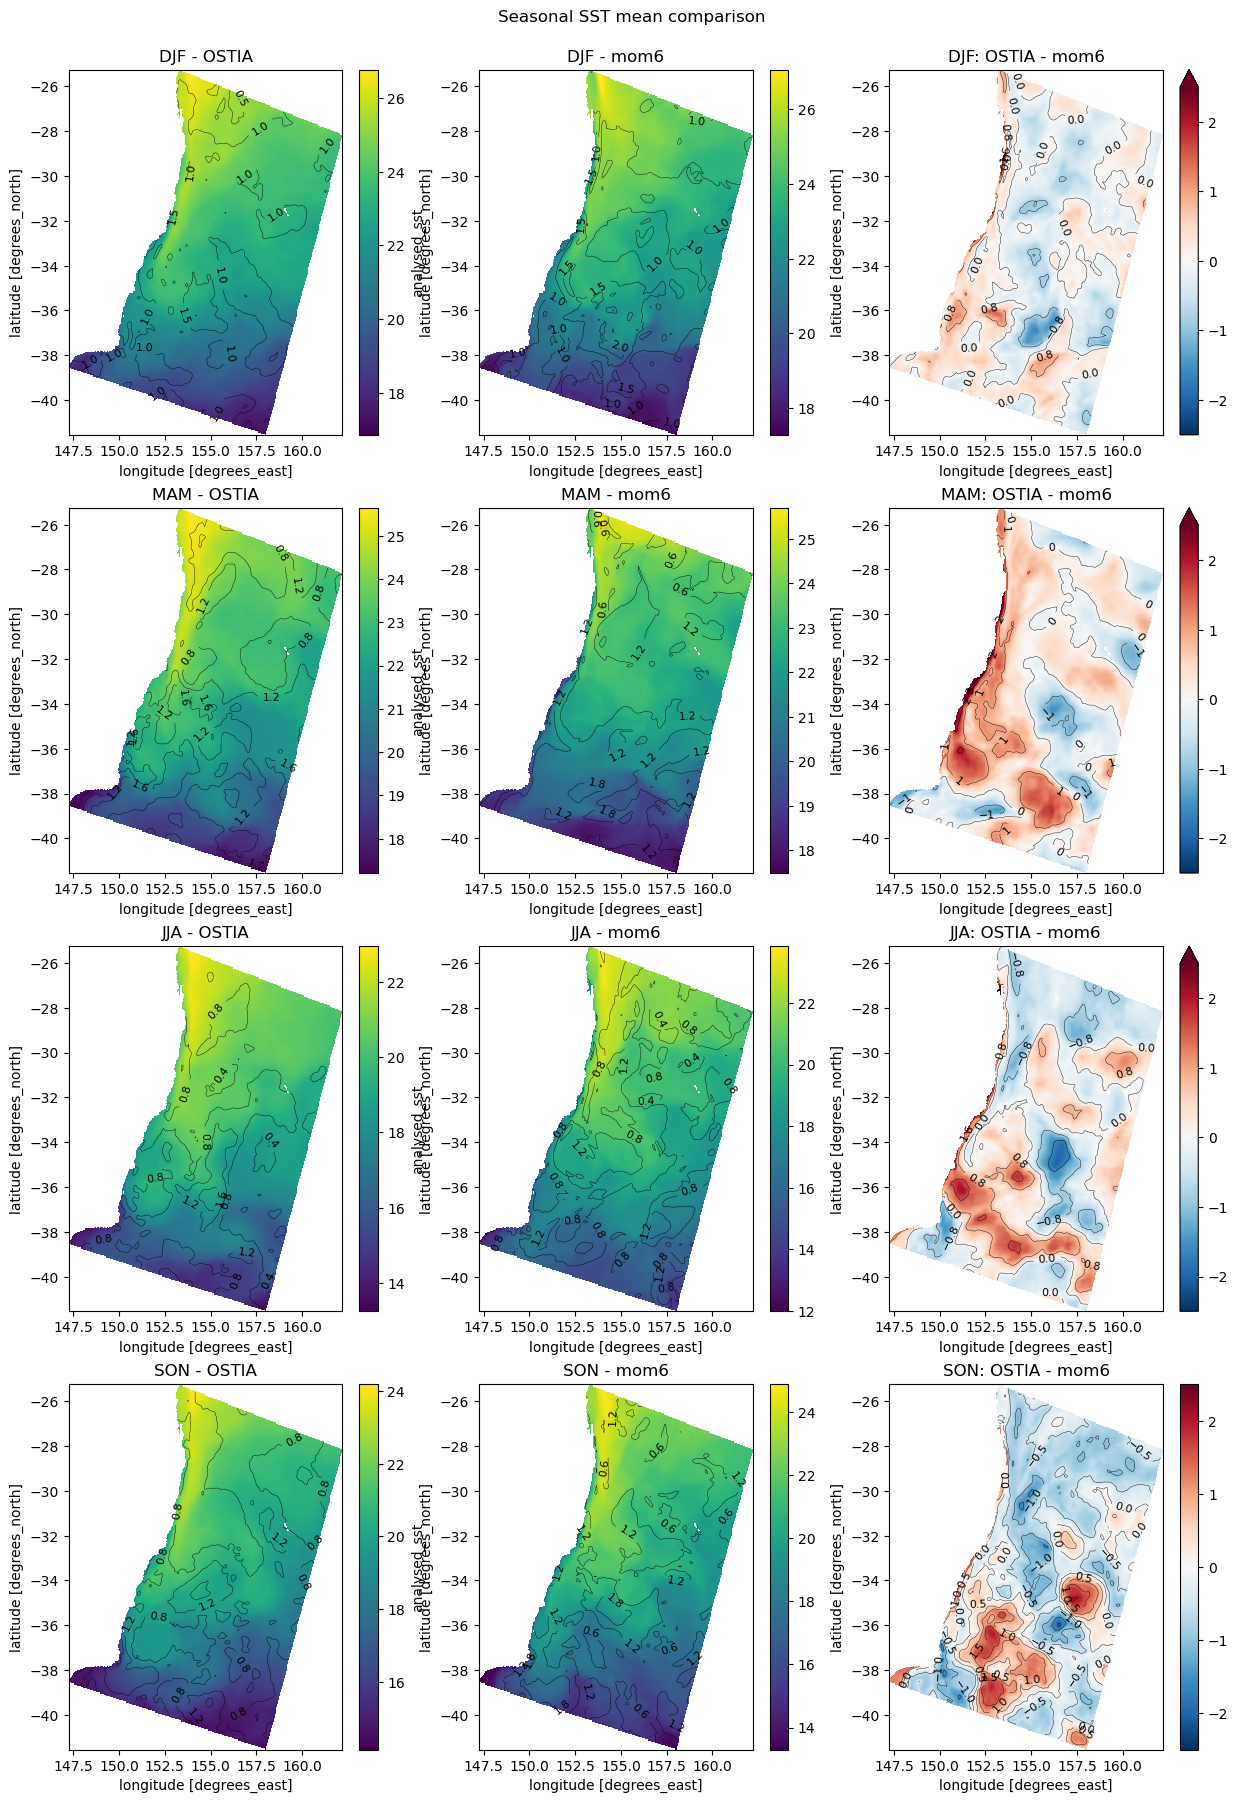

In [24]:
# Plotting each seasonal mean and calculating the difference between OSTIA and ROMS
# Isolines in the first two columns are STD. Last column is the difference between OSTIA and ROMS

for model in models:
    fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(15, 20))
    for enu, SS in enumerate(['DJF', 'MAM', 'JJA', 'SON']):
        # OSTIA
        ostia_seasons_mean.sel(season=SS).plot(ax=ax[enu, 0])
        cnt = ostia_seasons_std.sel(season=SS).plot.contour(ax=ax[enu, 0], levels=5, colors=['k'], linewidths=0.3)
        plt.clabel(cnt, inline=True, fontsize=8)
        # model
        temp_seasons_mean[model].sel(season=SS).plot(ax=ax[enu, 1])
        cnt = temp_seasons_std[model].sel(season=SS).plot.contour(ax=ax[enu, 1], levels=5, colors=['k'], linewidths=0.3)
        plt.clabel(cnt, inline=True, fontsize=8)
        
        # Calculating the difference
        diff = ostia_seasons_mean.sel(season=SS) - temp_seasons_mean[model].sel(season=SS)
        diff.plot(ax=ax[enu, 2], vmin=-2.5, vmax=2.5, cmap='RdBu_r')
        cnt = diff.plot.contour(ax=ax[enu, 2], levels=10, colors=['k'], linewidths=0.3)
        plt.clabel(cnt, inline=True, fontsize=8)
        
        # Adding titles
        ax[enu, 0].set_title(SS + ' - OSTIA')
        ax[enu, 1].set_title(SS + ' - ' + model)
        ax[enu, 2].set_title(SS + ': OSTIA - ' + model)
    fig.suptitle('Seasonal SST mean comparison');
    fig.subplots_adjust(top=0.95)


In [27]:
# Also, we can also calculate a spatial mean and plot the timeseries together
ostia_spatial_mean = ostia_masked.mean(['latitude', 'longitude'])
temp_spatial_mean = {}
rmse_temp = {}
for model in models:
    temp_spatial_mean[model] = temp_masked[model].mean(['latitude', 'longitude'])
    #Calculating the RMSE for the spatial mean
    rmse_temp[model] = ((ostia_spatial_mean - temp_spatial_mean[model])**2).mean() ** 0.5



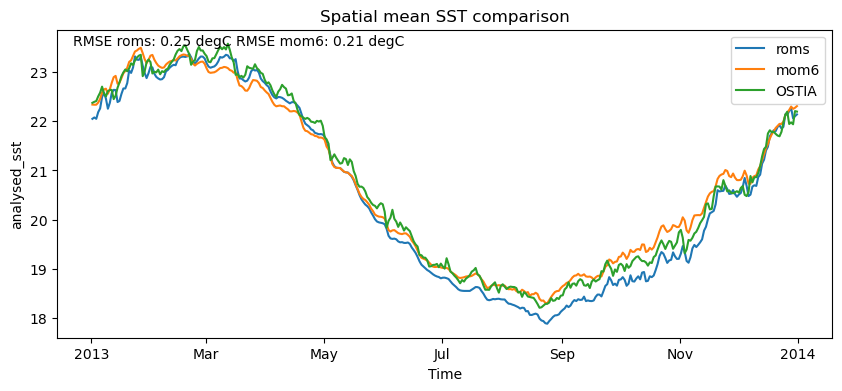

In [31]:
# Plotting the time series
fig, ax = plt.subplots(figsize=(10, 4))
for model in models:
    temp_spatial_mean[model].plot(ax=ax, label=model)
ostia_spatial_mean.plot(ax=ax, label='OSTIA')
ax.legend()

annotate_str = ''
for model in models:
    annotate_str = annotate_str + 'RMSE ' + model + ': {:.2f} degC '.format(rmse_temp[model].values) 
annotate_str
ax.annotate(annotate_str, xy=(0.02, 0.95), xycoords='axes fraction')
ax.set_title('Spatial mean SST comparison');
